<div style="text-align: center;">

# UNet Binary Segmentation

</div>

**Author**: Dr. Amir Omidvarnia  
**Email**: a.omidvarnia@fz-juelich.de  
**Affiliation**: Forschungszentrum Jülich, Germany  
**Event**: DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)  

**Data**: The dataset used in this tutorial is a subset of the SEM/TSEM dataset, which is available on [Github](https://github.com/BAMresearch/automatic-sem-image-segmentation/tree/master). It consists of SEM images and their corresponding binary masks for training, validation, and testing.

---

## Overview

This notebook trains a **UNet** model for binary segmentation of scanning electron microscopy (SEM) images. UNet is the most widely used encoder–decoder architecture for biomedical and materials image segmentation. Its characteristic skip connections between encoder and decoder layers allow the model to combine high-resolution spatial detail from early layers with semantic context from deeper layers, producing precise pixel-wise segmentation maps.

### Architecture

- **Encoder**: ResNet-34 backbone pretrained on ImageNet — provides multi-scale feature representations.
- **Decoder**: UNet skip-connection decoder that upsamples features back to the input resolution.
- **Output**: single-channel binary mask (foreground = 1, background = 0).

### Training strategy

- **Loss**: Dice loss — optimizes overlap between predicted and ground-truth masks, robust to class imbalance.
- **Optimizer**: Adam with cosine-annealing learning rate schedule.
- **Metric**: Intersection over Union (IoU) evaluated on the held-out test set.

### Workflow

1. Load and split the SEM dataset into train / validation / test sets.
2. Inspect sample image–mask pairs for quality control.
3. Train the UNet model and monitor Dice loss convergence.
4. Evaluate on the test set and report IoU.


## Computational Environment Setup

This section configures the numerical and deep-learning environment for binary image segmentation.
Core libraries for tensor computation, optimization, and model definition are imported, along with visualization tools for inspecting images and results.
Centralized logging ensures that training progress and scientific outcomes are traceable and reproducible across runs.

In [ ]:
import logging
import os
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    datefmt="%d:%m:%Y %H:%M:%S",
)

# Silence OpenCV/libtiff warnings; show only errors and above
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)

/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hardware Acceleration Selection

This block selects the most capable available compute backend (GPU, Apple Silicon, or CPU) for tensor operations.
Using specialized hardware accelerates convolutional neural network training and inference, which is crucial for large-scale image segmentation tasks.
Controlling the number of CPU threads ensures stable, reproducible performance when no dedicated accelerator is present.

In [2]:
# ----------------------------
# Set the device to GPU if available
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
logging.info(f"Using device: {device}")

26:02:2026 20:17:36 - Using device: mps


## UNet Segmentation Components

Here, the notebook locates the project root and imports modular components implementing the UNet-based segmentation pipeline.
The dataset class encapsulates loading and preprocessing of microscopy images and masks, while the UNet model definition specifies the encoder–decoder architecture for pixel-wise classification.
Dedicated training, testing, and visualization utilities separate scientific logic (loss, metrics, sampling) from experimental configuration, enabling systematic studies and reproducible benchmarks.

In [3]:
try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()
cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent
if repo_root is None:
    repo_root = Path.cwd()
modules_path = str(repo_root / 'src')
if modules_path not in sys.path:
    sys.path.insert(0, modules_path)
print(f'Added src path to sys.path: {modules_path}')

from segment_unet import UNetModel, Dataset, train_model, test_model, visualize


Added modules path to sys.path: /Users/amir/GIT_repositories/DPG2026_release/modules


## Experiment Configuration & Hyperparameters

This section defines the experimental configuration for binary segmentation on the chosen dataset.
Directory paths specify where raw images, masks, and derived outputs are stored, ensuring a clear separation between data and results.
Hyperparameters such as number of epochs, learning rate, scheduler floor, batch size, and spatial resolution govern the optimization dynamics and the spatial scale at which structures in the electrochemical images are analyzed.

In [4]:
# Create a directory to store the output masks
output_dir = os.path.join(repo_root, "Output_images", "UNet")
os.makedirs(output_dir, exist_ok=True)

# ----------------------------
# Define the hyperparameters
# ----------------------------
epochs_max = 20  # Number of epochs to train the model
adam_lr = 2e-4  # Learning rate for the Adam optimizer
eta_min = 1e-5  # Minimum learning rate for the scheduler
batch_size = 8  # Batch size for training
input_image_reshape = (320, 320)  # Desired shape for the input images and masks
foreground_class = 1  # 1 for binary segmentation

## Dataset Partitioning and Loading

This block specifies the physical location of the SEM/TEM image corpus and constructs training, validation, and test splits.
Each split represents a distinct statistical sample of the underlying imaging process, enabling unbiased estimation of generalization performance.
DataLoader objects stream mini-batches of paired images and masks, which is essential for stochastic gradient-based optimization and for preserving the spatial correspondence required in segmentation.

In [5]:
data_dir = os.path.join(repo_root, "Train_test_images", "SEM")
x_train_dir = os.path.join(data_dir, "images", "train")
y_train_dir = os.path.join(data_dir, "masks", "train")

x_val_dir = os.path.join(data_dir, "images", "val")
y_val_dir = os.path.join(data_dir, "masks", "val")

x_test_dir = os.path.join(data_dir, "images", "test")
y_test_dir = os.path.join(data_dir, "masks", "test")

train_dataset = Dataset(
    x_train_dir,
    y_train_dir,
    input_image_reshape=input_image_reshape,
    foreground_class=foreground_class,
)
valid_dataset = Dataset(
    x_val_dir,
    y_val_dir,
    input_image_reshape=input_image_reshape,
    foreground_class=foreground_class,
)
test_dataset = Dataset(
    x_test_dir,
    y_test_dir,
    input_image_reshape=input_image_reshape,
    foreground_class=foreground_class,
)

image, mask = train_dataset[0]
logging.info(f"Unique values in mask: {np.unique(mask)}")
logging.info(f"Image shape: {image.shape}")
logging.info(f"Mask shape: {mask.shape}")

# ----------------------------
# Create the dataloaders using the datasets
# ----------------------------
logging.info(f"Train size: {len(train_dataset)}")
logging.info(f"Valid size: {len(valid_dataset)}")
logging.info(f"Test size: {len(test_dataset)}")

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

26:02:2026 20:17:36 - Unique values in mask: [0 1]
26:02:2026 20:17:36 - Image shape: torch.Size([1, 320, 320])
26:02:2026 20:17:36 - Mask shape: torch.Size([320, 320])
26:02:2026 20:17:36 - Train size: 30
26:02:2026 20:17:36 - Valid size: 5
26:02:2026 20:17:36 - Test size: 5


## Qualitative Data Inspection

This section visualizes representative image–mask pairs from the training, validation, and test sets.
By overlaying or juxtaposing raw microscopy data with their binary annotations, one can verify label quality, contrast, and the morphological characteristics of foreground structures.
Such qualitative checks are critical to ensure that subsequent quantitative training truly reflects the underlying electrochemical phenomena rather than artefacts or mislabeling.

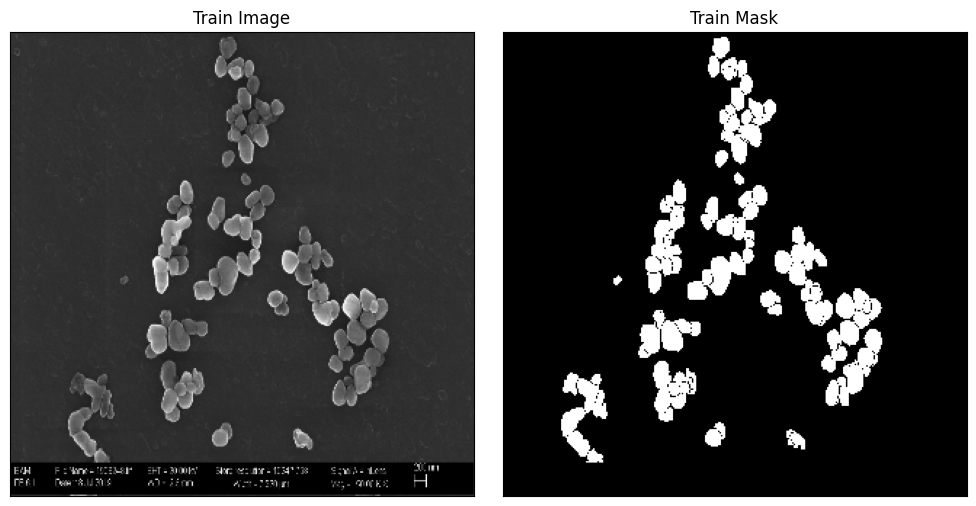

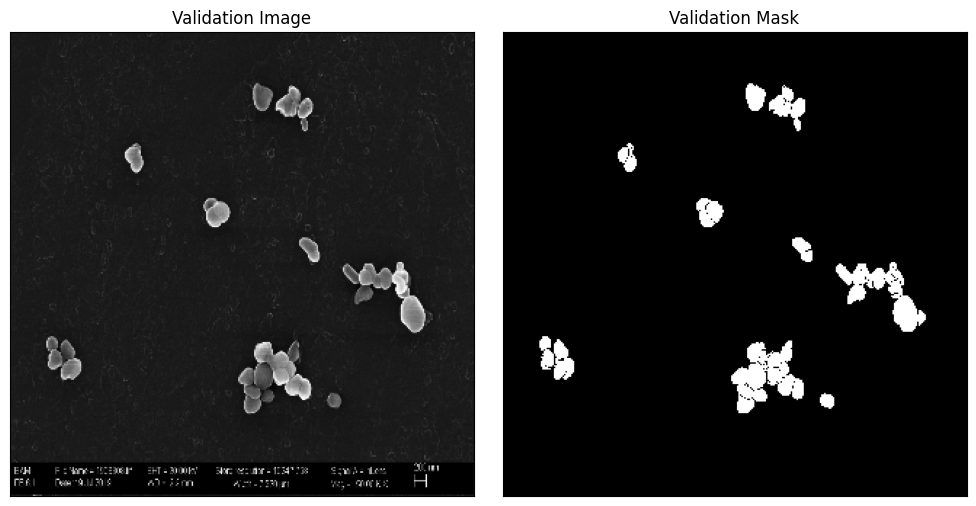

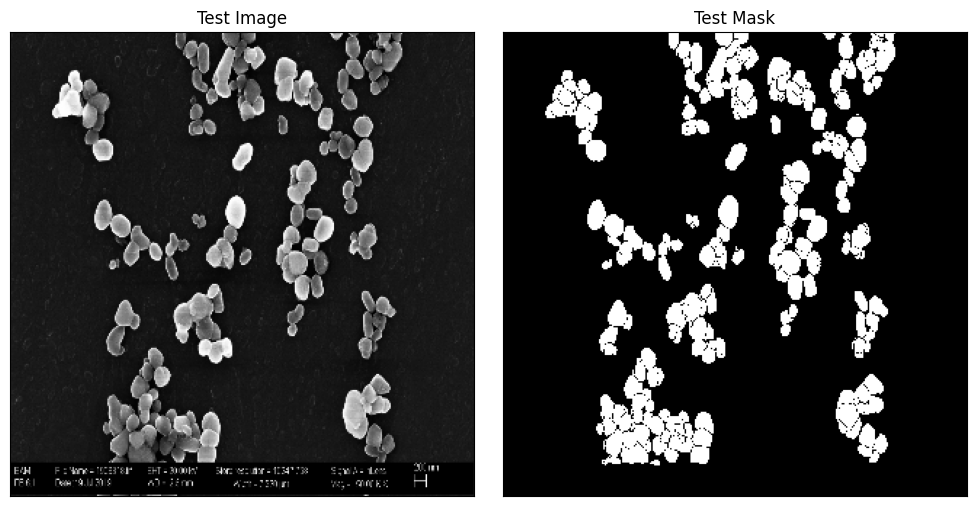

In [6]:
# Visualize and save train sample
sample = train_dataset[0]
visualize(
    output_dir,
    "train_sample.png",
    train_image=sample[0].numpy().transpose(1, 2, 0),
    train_mask=sample[1].squeeze(),
)

# Visualize and save validation sample
sample = valid_dataset[0]
visualize(
    output_dir,
    "validation_sample.png",
    validation_image=sample[0].numpy().transpose(1, 2, 0),
    validation_mask=sample[1].squeeze(),
)

# Visualize and save test sample
sample = test_dataset[0]
visualize(
    output_dir,
    "test_sample.png",
    test_image=sample[0].numpy().transpose(1, 2, 0),
    test_mask=sample[1].squeeze(),
)

## UNet Training Procedure

This block instantiates a UNet model with a ResNet encoder tailored for binary segmentation of microscopy images.
The optimization scheme combines Adam with a cosine-annealing learning-rate schedule to efficiently traverse the non-convex loss landscape.
Dice loss emphasizes overlap between predicted and ground-truth masks, which is particularly suitable for imbalanced foreground–background problems common in electrochemical imaging.

In [7]:
max_iter = epochs_max * len(train_dataloader)  # Total number of iterations

model = UNetModel("Unet", "resnet34", in_channels=3, out_classes=1, device=device)

# Training loop
model = model.to(device)

# Define the Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=adam_lr)

# Define the learning rate scheduler
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iter, eta_min=eta_min)

# Define the loss function
loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

# Train the model
history = train_model(
    model,
    train_dataloader,
    valid_dataloader,
    optimizer,
    scheduler,
    loss_fn,
    device,
    epochs_max,
)

Evaluating: 100%|██████████| 1/1 [00:00<00:00,  8.80it/s]
26:02:2026 20:17:38 - Epoch 1/20, Training Loss: 0.84, Validation Loss: 0.85
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 27.10it/s]
26:02:2026 20:17:39 - Epoch 2/20, Training Loss: 0.78, Validation Loss: 0.83
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 27.27it/s]
26:02:2026 20:17:39 - Epoch 3/20, Training Loss: 0.74, Validation Loss: 0.79
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 28.00it/s]
26:02:2026 20:17:40 - Epoch 4/20, Training Loss: 0.71, Validation Loss: 0.75
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 27.10it/s]
26:02:2026 20:17:41 - Epoch 5/20, Training Loss: 0.71, Validation Loss: 0.74
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 26.88it/s]
26:02:2026 20:17:41 - Epoch 6/20, Training Loss: 0.67, Validation Loss: 0.71
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 25.59it/s]
26:02:2026 20:17:42 - Epoch 7/20, Training Loss: 0.66, Validation Loss: 0.69
Evaluating: 100%|██████████| 1/1 [00:00<00:00, 25.06it/

## Learning Curve Analysis

This section visualizes the evolution of training and validation loss across epochs.
The relative behavior of these curves reveals optimization progress, potential underfitting or overfitting, and the adequacy of the chosen model capacity and regularization.
In the context of segmentation, stable convergence and close alignment of both curves indicate that the network captures relevant morphological patterns without memorizing noise.

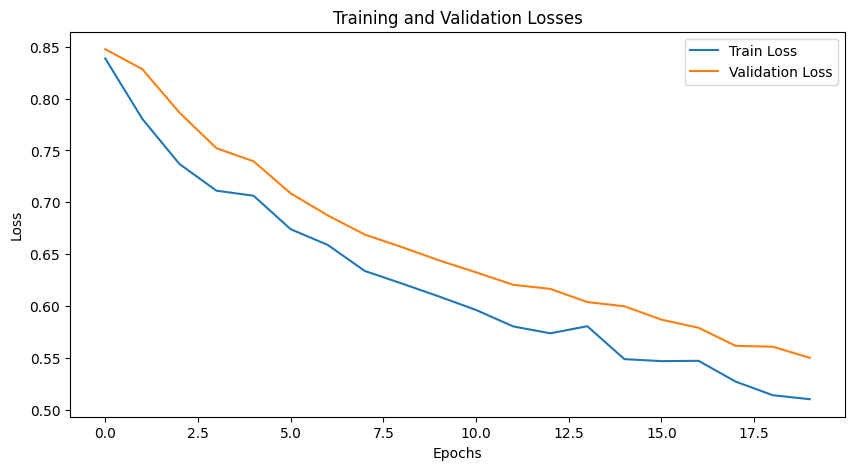

In [8]:
# Visualize the training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(history["train_losses"], label="Train Loss")
plt.plot(history["val_losses"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Losses")
plt.legend()
# plt.savefig(os.path.join(output_dir, "train_val_losses.png"))
# plt.close()

## Test Evaluation and Metrics

The final evaluation step applies the trained model to a held-out test set to quantify generalization performance.
The reported test loss and Intersection-over-Union (IoU) score summarize how well predicted masks overlap with ground-truth annotations at the pixel level.
Saving output masks enables visual inspection of successes and failure cases, which is essential for interpreting model behavior on real electrochemical microstructures.

Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.95it/s]
26:02:2026 20:17:51 - Test Loss: 0.33
26:02:2026 20:17:51 - Test Loss: 0.3277938961982727, IoU Score: 0.7690140008926392
26:02:2026 20:17:51 - The output masks are saved in /Users/amir/GIT_repositories/DPG2026_release/Output_images/UNet.


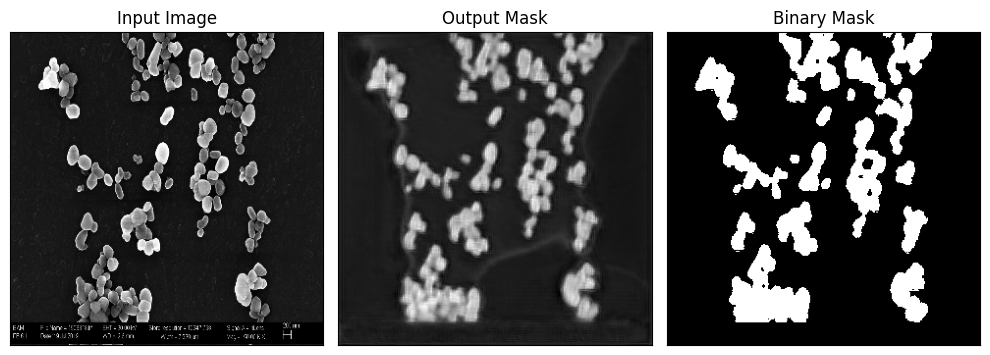

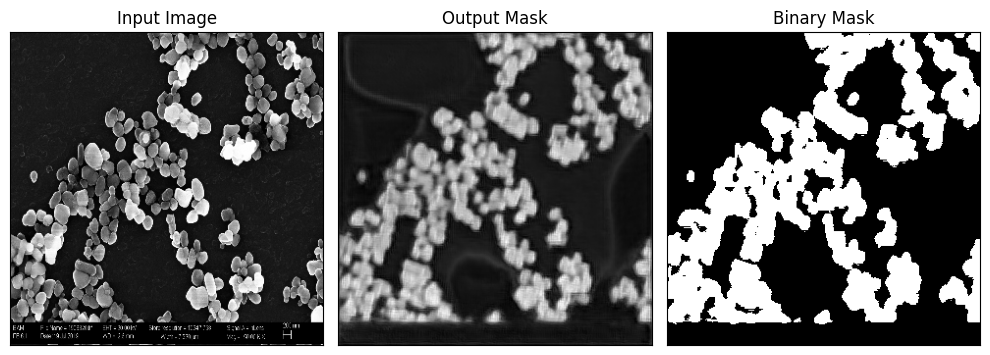

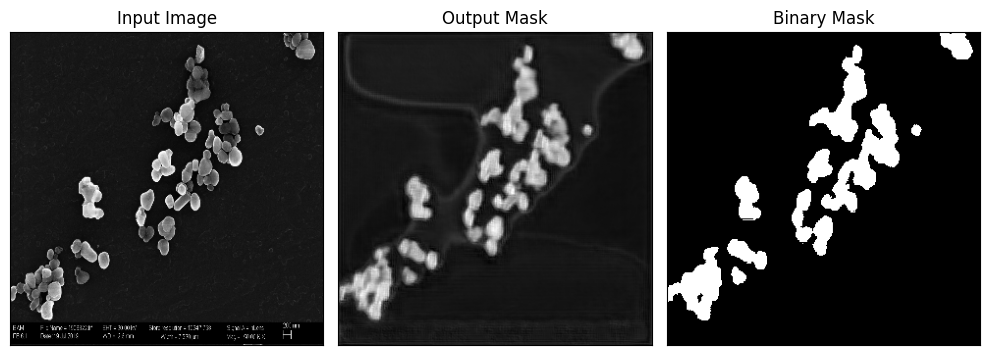

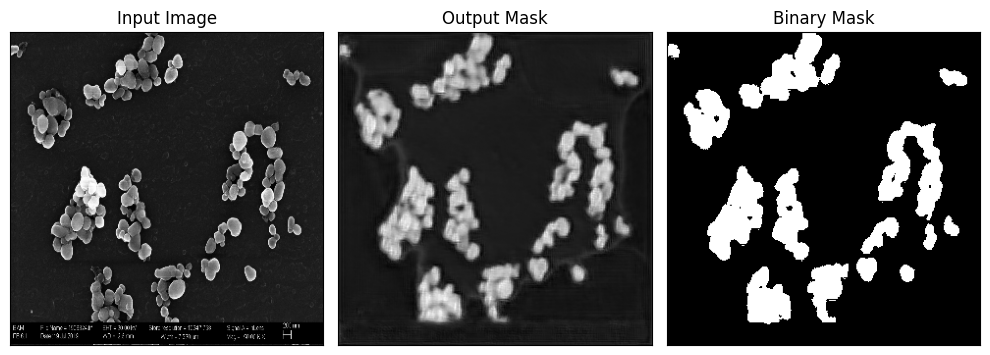

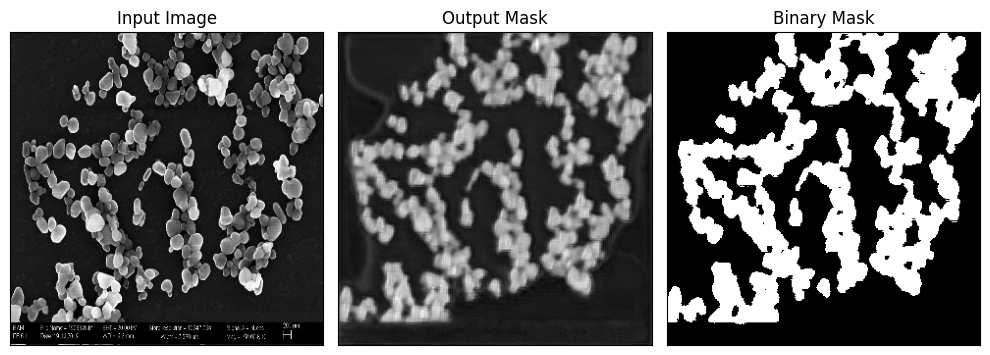

In [9]:
# Evaluate the model
test_loss = test_model(model, output_dir, test_dataloader, loss_fn, device)

logging.info(f"Test Loss: {test_loss[0]}, IoU Score: {test_loss[1]}")
logging.info(f"The output masks are saved in {output_dir}.")